In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import MaxNLocator, MultipleLocator

import warnings
warnings.filterwarnings('ignore')

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]


In [16]:
proj_path = "/data/gc_openPMD-viewer/"

df_path = proj_path + "results/final/large_2GB_mem.csv"
# df_path = "/data/gc/rocksdb-index/openPMD-viewer/results/final/large.csv"
df = pd.read_csv(df_path, header=[0])

In [17]:
def process_df(df, lower_bound, upper_bound, target_percentage=None):
    print("Before Sampling, each group size:")
    print(df.groupby(['target_percentage', 'select_set']).size() / 7)

    number_of_each_group = 10
    if target_percentage:
        # Filter DataFrame by target_percentage
        df_filtered = df[df['target_percentage'] == target_percentage]
    else:
        df_filtered = df

    # Group by select_set and get unique envelope values for each group
    unique_envelopes = df_filtered.groupby('select_set')['envelope'].unique().reset_index()

    # Rename columns for clarity
    unique_envelopes.columns = ['select_set', 'unique_envelopes']

    # print the number of unique envelopes for each group
    # for i in range(number_of_each_group):
    #     print(f"Group {i+1} has {len(unique_envelopes['unique_envelopes'][i])} unique envelopes.")

    # Function to sample envelopes
    # def sample_envelopes(envelopes, n):
    #     return list(envelopes.sample(n=min(n, len(envelopes))))

    # Apply the sampling to each group
    # unique_envelopes['sampled_envelopes'] = unique_envelopes['unique_envelopes'].apply(lambda x: list(pd.Series(x).sample(number_of_each_group)))
    # # unique_envelopes['sampled_envelopes'] = unique_envelopes['unique_envelopes'].apply(lambda x: sample_envelopes(pd.Series(x), number_of_each_group))
    #
    # # Clean up the DataFrame by dropping the original unique envelopes column
    # for i in range(number_of_each_group):
    #     print(f"Group {i+1} has {len(unique_envelopes['sampled_envelopes'][i])} sampled envelopes.")

    unique_envelopes['sampled_envelopes'] = unique_envelopes['unique_envelopes']

    # Explode the sampled_envelopes into separate rows
    exploded_unique_envelopes = unique_envelopes.explode('sampled_envelopes')

    # Merge the exploded_unique_envelopes back to df_filtered to keep only relevant rows
    filtered_df = df_filtered.merge(exploded_unique_envelopes[['select_set', 'sampled_envelopes']],
                                    left_on=['select_set', 'envelope'],
                                    right_on=['select_set', 'sampled_envelopes'])

    # Drop the 'sampled_envelopes' column as it's now redundant
    filtered_df = filtered_df.drop(columns='sampled_envelopes')

    print("")
    print(filtered_df.groupby(['target_percentage', 'select_set']).size() / 7)

    filtered_df = filtered_df[['select_set', 'test_type', 'query_index_time_elapsed', 'remove_duplication_time_elapsed',
                               'sort_block_metadata_time_elapsed', 'find_optimal_read_solution_time_elapsed',
                               'get_target_data_time_elapsed', 'get_support_data_time_elapsed',
                               'data_calculation_time_elapsed', 'data_apply_select_time_elapsed', 'apply_particle_level_select_array_time_elapsed', 'total_time_elapsed', 'query_result_size', 'chunk_range_size', 'total_memory_used', 'data_size']]

    filtered_df['indexing'] = filtered_df['query_index_time_elapsed'] + df['remove_duplication_time_elapsed'] + df['sort_block_metadata_time_elapsed'] + df['find_optimal_read_solution_time_elapsed']
    filtered_df['IO_time'] = filtered_df['get_target_data_time_elapsed'] + df['get_support_data_time_elapsed']
    filtered_df['calculation'] = filtered_df['data_calculation_time_elapsed'] + df['data_apply_select_time_elapsed'] + df['apply_particle_level_select_array_time_elapsed']

    filtered_df = filtered_df[['select_set', 'test_type', 'indexing', 'IO_time', 'calculation', 'total_time_elapsed', 'query_result_size', 'chunk_range_size', 'total_memory_used', 'data_size']]

    filtered_df = filtered_df[filtered_df['data_size'] <= upper_bound]
    filtered_df = filtered_df[filtered_df['data_size'] >= lower_bound]

    # Group by select_set and test_type, then compute the average value
    averaged_df = filtered_df.groupby(['select_set', 'test_type']).mean().reset_index()


    # only keep the select_set with specific values: ('ux',),  ('ux','uy'),  ('ux','uy','uz'),  ('ux','uy','uz','x'), ('ux','uy','uz','x','y'), ('ux','uy','uz','x','y','z')
    averaged_df = averaged_df[averaged_df['select_set'].isin(["('ux',)", "('ux','uy')", "('ux','uy','uz')", "('ux','uy','uz','x')", "('ux','uy','uz','x','y')", "('ux','uy','uz','x','y','z')"])]

    # a new column to indicate the length of select_set
    averaged_df['select_set_length'] = averaged_df['select_set'].apply(lambda x: len(eval(x)))
    averaged_df['plot_from_0'] = averaged_df['select_set_length'].apply(lambda x: x - 1)

    # sort by select_set_length
    averaged_df = averaged_df.sort_values('select_set_length')

    averaged_df['direct_io_number'] = averaged_df['select_set_length'] * averaged_df['query_result_size']
    averaged_df['grouping_io_number'] = averaged_df['select_set_length'] * averaged_df['chunk_range_size']
    return averaged_df


In [18]:
# Define a formatter function for y-axis labels
def exp_formatter(y, pos):
    if y == 0:
        return r"0"
    return r"$\mathregular{{10}}^{{\mathregular{{{}}}}}$".format(int(y))

In [19]:
global_tick_fontsize = 20
global_label_fontsize = 24
global_annotation_fontsize = 18
global_legend_fontsize = 18

In [20]:
averaged_df = process_df(df, 1100000, 1500000, "0.01%")

Before Sampling, each group size:
target_percentage  select_set                  
0.01%              ('ux','uy')                     31.428571
                   ('ux','uy','uz')                17.285714
                   ('ux','uy','uz','x')            25.142857
                   ('ux','uy','uz','x','y')        21.571429
                   ('ux','uy','uz','x','y','z')    51.857143
                   ('ux',)                         15.714286
dtype: float64

target_percentage  select_set                  
0.01%              ('ux','uy')                     31.428571
                   ('ux','uy','uz')                17.285714
                   ('ux','uy','uz','x')            25.142857
                   ('ux','uy','uz','x','y')        21.571429
                   ('ux','uy','uz','x','y','z')    51.857143
                   ('ux',)                         15.714286
dtype: float64


[1000000. 1200000. 1400000. 1600000.]
[-500.    0.  500. 1000. 1500. 2000.]


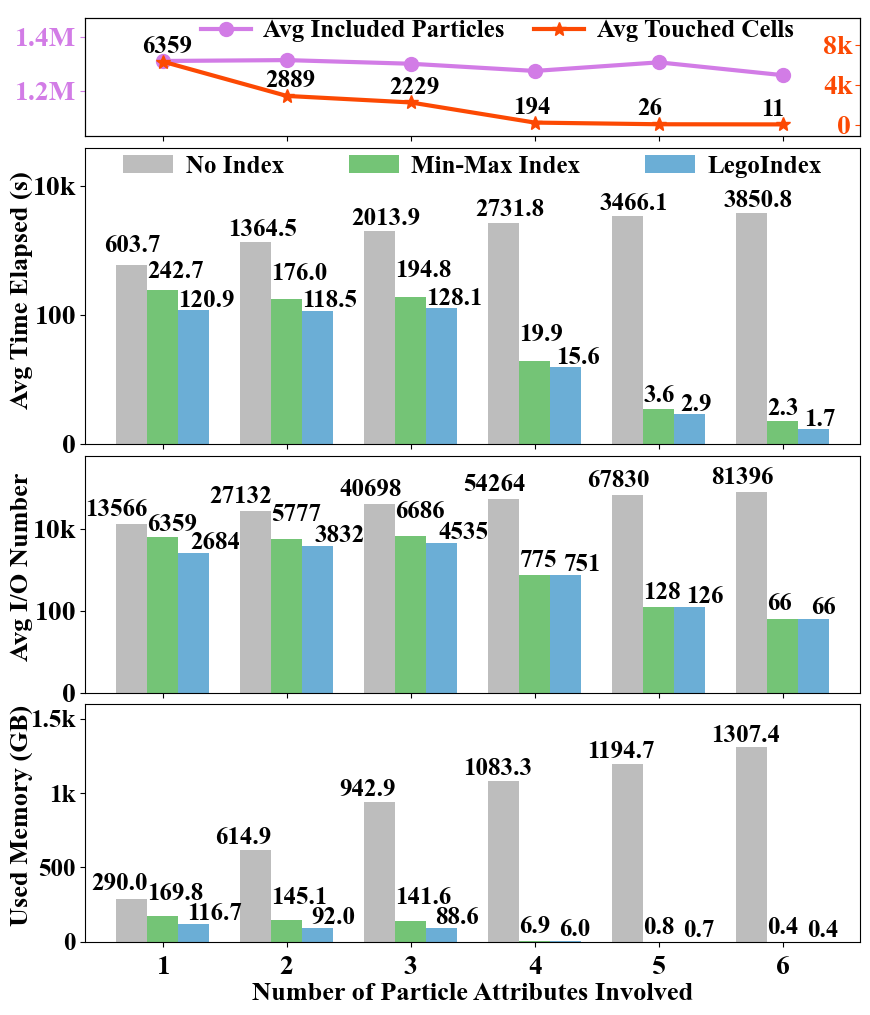

In [21]:
# only keep the test_type with specific values: 1 and 25\
plot_df = averaged_df[averaged_df['test_type'].isin([1, 2, 25])]

row_ratios = [2, 5, 4, 4]

# fig, ax = plt.subplots()
# set figure size
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10, 12), gridspec_kw={'height_ratios': row_ratios})

''' subplot 1 '''
ax = axes[0]
plot_df[averaged_df['test_type'] == 25].pivot(index='plot_from_0', columns='test_type', values='data_size').plot(kind='line', ax=ax, color='#d27ce6', marker='o', markersize=10, linewidth=3)
plt.xticks(rotation=0)
ax.set_ylim(1.03e6, 1.47e6)

ax.yaxis.set_major_locator(MultipleLocator(2e5))
current_values = ax.get_yticks()
print(current_values)

# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
ax.set_yticklabels([f"{round(y / 1000000, 1)}M" if y != 0 else "0" for y in current_values])
# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize, colors='#d27ce6')  # Adjust label size as needed

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

# Remove the legend
# ax.get_legend().remove()
legend = ax.legend(title='', loc='upper left', labels=['Avg Included Particles'], fontsize=global_legend_fontsize, ncol=1, frameon=False, bbox_to_anchor=(0.12, 1.17), columnspacing=2.6, handletextpad=0.5)
for text in legend.get_texts():
    text.set_fontweight('bold')

ax2 = ax.twinx()
# ax2.set_xlim((ax.get_xlim()))

# ax2.yaxis.set_tick_params(direction='in')  # Move ticks inside
ax2.yaxis.set_tick_params(direction='in', pad=-27)  # Move ticks inside
# ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()


plot_df[plot_df['test_type'] == 25].pivot(index='plot_from_0', columns='test_type', values='query_result_size').plot(kind='line', ax=ax2, color='#fc4903', marker='*', markersize=10, linewidth=3)

# Annotate each data point
for i, (x, y) in enumerate(zip(ax2.lines[0].get_xdata(), ax2.lines[0].get_ydata())):
    ax2.annotate(
        str(round(y)),  # Text label
        (x - 0.17, y + 900),  # Position (adjust y + 200 for visibility)
        fontsize=global_annotation_fontsize,
        fontweight='bold'
    )


# ax.set_autoscale_on(False)
ax2.set_ylim(-1200, 10800)

# y label
# ax.set_ylabel("Avg Touched Cells", fontsize=global_label_fontsize - 5, labelpad=25, fontweight='bold')
ax2.yaxis.set_label_coords(-0.068, 0.5)

ax2.yaxis.set_major_locator(MultipleLocator(4000))
current_values = ax2.get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# ax2.set_yticklabels([f"{int(y / 1000)}k" if y != 0 else "0" for y in current_values])
y_ticks = ["-1", "  0", "4k", "8k"]
ax2.set_yticklabels(y_ticks)
ax2.tick_params(axis='y', labelsize=global_tick_fontsize, colors='#fc4903')  # Adjust label size as needed


for label in ax2.get_yticklabels():
    label.set_fontweight('bold')

legend = ax2.legend(title='', loc='upper left', labels=['Avg Touched Cells'], fontsize=global_legend_fontsize, ncol=1, frameon=False, bbox_to_anchor=(0.55, 1.17), columnspacing=2.6, handletextpad=0.5)
for text in legend.get_texts():
    text.set_fontweight('bold')


''' subplot 2 '''
# the value difference between test_type 1 and 25 is too large, so we use log scale
plot_df['total_time_elapsed'] = plot_df['total_time_elapsed'].apply(lambda x: np.log10(x))

# log for query_result_size and chunk_range_size
# plot_df['query_result_size'] = plot_df['query_result_size'].apply(lambda x: np.log10(x))
# plot_df['chunk_range_size'] = plot_df['chunk_range_size'].apply(lambda x: np.log10(x))

ax = axes[1]
# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='test_type', values='total_time_elapsed').plot(kind='bar', ax=ax, width=0.75, color=['#bdbdbd', '#74c476', '#6baed6'])
plt.xticks(rotation=0)
legend = ax.legend(title='', loc='upper left', labels=['No Index', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(0.02, 1.05), columnspacing=2.6, handletextpad=0.5)
# legend = ax.legend(title='', loc='upper left', labels=['OpenPMD-viewer', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(0, 1.13), columnspacing=0.8)

for text in legend.get_texts():
    text.set_fontweight('bold')

# mark the number on the top of each bar before log
for i, p in enumerate(ax.patches):
    if i == 0:
        ax.annotate(str(round(10**p.get_height(), 1)), (p.get_x() - 0.1, p.get_height() + 0.20), fontsize=global_annotation_fontsize, fontweight='bold')
    elif i < 6:
        ax.annotate(str(round(10**p.get_height(), 1)), (p.get_x() - 0.1, p.get_height() + 0.10), fontsize=global_annotation_fontsize, fontweight='bold')
    elif i == 6:
        ax.annotate(str(round(10**p.get_height(), 1)), (p.get_x(), p.get_height() + 0.20), fontsize=global_annotation_fontsize, fontweight='bold')
    elif i <= 9:
        ax.annotate(str(round(10**p.get_height(), 1)), (p.get_x(), p.get_height() + 0.3), fontsize=global_annotation_fontsize, fontweight='bold')
    elif i <= 11:
        ax.annotate(str(round(10**p.get_height(), 1)), (p.get_x(), p.get_height() + 0.1), fontsize=global_annotation_fontsize, fontweight='bold')
    elif i <= 14:
        ax.annotate(str(round(10**p.get_height(), 1)), (p.get_x(), p.get_height() + 0.05), fontsize=global_annotation_fontsize, fontweight='bold')
    else:
        ax.annotate(str(round(10**p.get_height(), 1)), (p.get_x() + 0.05, p.get_height() + 0.05), fontsize=global_annotation_fontsize, fontweight='bold')

# plt.xticks(rotation=0)
# plt y range
ax.set_ylim(0, 4.6)

# x label
ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
# y label
ax.set_ylabel("Avg Time Elapsed (s)", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.068, 0.52)

current_values = ax.get_yticks()

# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
ax.yaxis.set_major_locator(MultipleLocator(2))
y_ticks = ["-1", "0", "100", "10k"]
# ax.set_yticklabels([str(int(pow(10, y*2))) if y != 0 else "0" for y in current_values])
ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize - 2)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

# plt.xticks(fontweight='bold')
# plt.yticks(fontweight='bold')

ax.tick_params(axis='y', labelsize=global_tick_fontsize)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
plt.subplots_adjust(hspace=0.05)






''' subplot 3 '''
ax = axes[2]
plot_df.loc[plot_df['test_type'] == 1, "grouping_io_number"] = 13566 * plot_df.loc[plot_df['test_type'] == 1, "select_set_length"]
plot_df['grouping_io_number'] = plot_df['grouping_io_number'].apply(lambda x: np.log10(x))
plot_df.pivot(index='select_set_length', columns='test_type', values='grouping_io_number').plot(kind='bar', ax=ax, width=0.75, color=['#bdbdbd', '#74c476', '#6baed6'])

for i, p in enumerate(ax.patches):
    if i < 2:
        ax.annotate(str(round(10**p.get_height())), (p.get_x() - 0.25, p.get_height() + 0.20), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i < 6:
        ax.annotate(str(round(10**p.get_height())), (p.get_x() - 0.2, p.get_height() + 0.20), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i == 6:
        ax.annotate(str(round(10**p.get_height())), (p.get_x(), p.get_height() + 0.15), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i < 9:
        ax.annotate(str(round(10**p.get_height())), (p.get_x(), p.get_height() + 0.45), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i > 11:
        ax.annotate(str(round(10**p.get_height())), (p.get_x() + 0.1, p.get_height() + 0.10), fontsize=global_annotation_fontsize , fontweight='bold')
    else:
        ax.annotate(str(round(10**p.get_height())), (p.get_x(), p.get_height() + 0.20), fontsize=global_annotation_fontsize , fontweight='bold')

# plt.xticks(rotation=0)
# plt y range
ax.set_ylim(0, 5.8)
# x label
ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
# y label
ax.set_ylabel("Avg I/O Number", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.068, 0.53)

current_values = ax.get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
y_ticks = ["0", "100", "10k"]
# ax.set_yticklabels([str(int(pow(10, y*2))) if y != 0 else "0" for y in current_values])
ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize - 2)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

# plt.xticks(fontweight='bold')
# plt.yticks(fontweight='bold')

ax.tick_params(axis='y', labelsize=global_tick_fontsize)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.get_legend().remove()

''' subplot 4 '''
ax = axes[3]
plot_df.pivot(index='select_set_length', columns='test_type', values='total_memory_used').plot(kind='bar', ax=ax, width=0.75, color=['#bdbdbd', '#74c476', '#6baed6'])
ax.tick_params(axis='x', rotation=0)

for i, p in enumerate(ax.patches):
    if i == 0:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.2, p.get_height() + 60), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i < 6:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.2, p.get_height() + 40), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i < 9:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 110), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i > 11:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.07, p.get_height() + 30), fontsize=global_annotation_fontsize , fontweight='bold')
    else:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 50), fontsize=global_annotation_fontsize , fontweight='bold')

ax.set_ylim(0, 1599)
# x label
ax.yaxis.set_label_coords(-0.068, 0.53)
ax.yaxis.set_major_locator(MultipleLocator(500))

current_values = ax.get_yticks()
print(current_values)
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# ax.set_yticklabels([str(int(y)) if y != 0 else "0" for y in current_values])
y_ticks = ["-500", "0", "500", "1k", "1.5k"]
ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize - 2)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)


ax.set_ylabel("Used Memory (GB)", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.068, 0.53)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.get_legend().remove()
ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize - 5, labelpad=2, fontweight='bold')
""""""
plt.savefig(proj_path + "plot/final/overall_query_time_comparison_large_v2.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()
print()

[1000000. 1200000. 1400000. 1600000.]
[-500.    0.  500. 1000. 1500. 2000.]


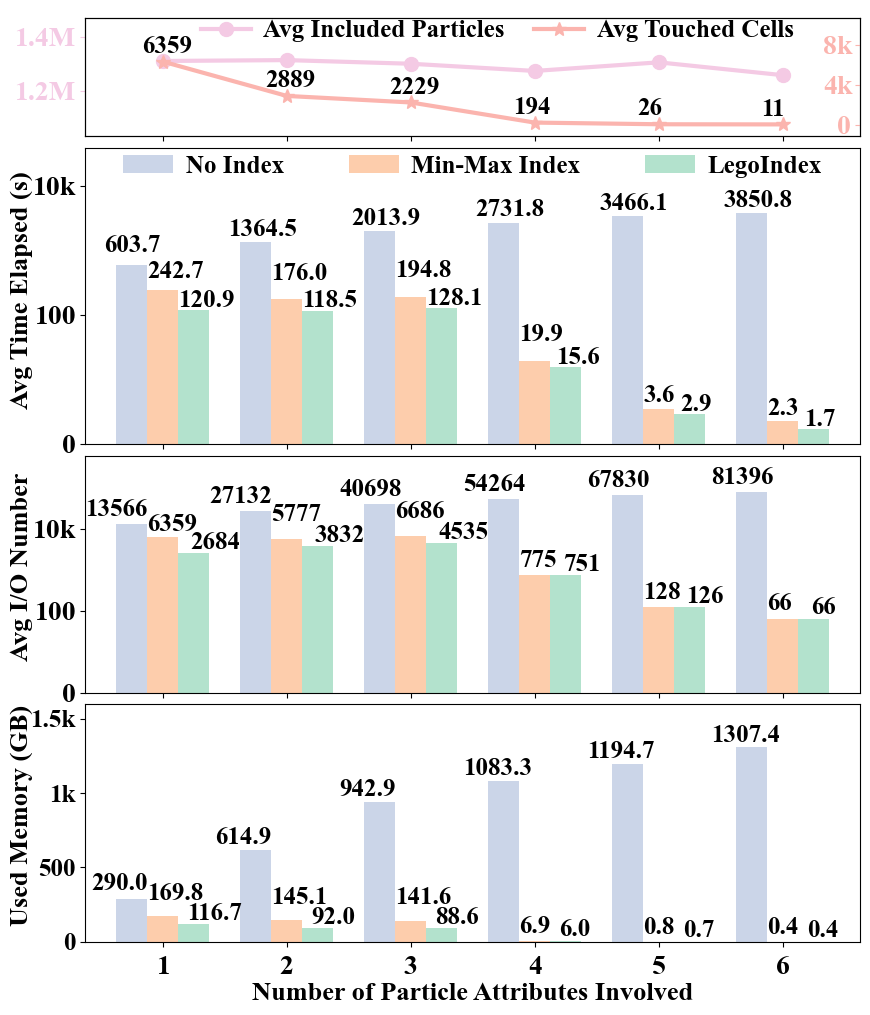

In [22]:
# only keep the test_type with specific values: 1 and 25\
plot_df = averaged_df[averaged_df['test_type'].isin([1, 2, 25])]

row_ratios = [2, 5, 4, 4]

# fig, ax = plt.subplots()
# set figure size
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10, 12), gridspec_kw={'height_ratios': row_ratios})

''' subplot 1 '''
ax = axes[0]
plot_df[averaged_df['test_type'] == 25].pivot(index='plot_from_0', columns='test_type', values='data_size').plot(kind='line', ax=ax, color='#f4cae4', marker='o', markersize=10, linewidth=3)
plt.xticks(rotation=0)
ax.set_ylim(1.03e6, 1.47e6)

ax.yaxis.set_major_locator(MultipleLocator(2e5))
current_values = ax.get_yticks()
print(current_values)

# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
ax.set_yticklabels([f"{round(y / 1000000, 1)}M" if y != 0 else "0" for y in current_values])
# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize, colors='#f4cae4')  # Adjust label size as needed

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

# Remove the legend
# ax.get_legend().remove()
legend = ax.legend(title='', loc='upper left', labels=['Avg Included Particles'], fontsize=global_legend_fontsize, ncol=1, frameon=False, bbox_to_anchor=(0.12, 1.17), columnspacing=2.6, handletextpad=0.5)
for text in legend.get_texts():
    text.set_fontweight('bold')

ax2 = ax.twinx()
# ax2.set_xlim((ax.get_xlim()))

# ax2.yaxis.set_tick_params(direction='in')  # Move ticks inside
ax2.yaxis.set_tick_params(direction='in', pad=-27)  # Move ticks inside
# ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()


plot_df[plot_df['test_type'] == 25].pivot(index='plot_from_0', columns='test_type', values='query_result_size').plot(kind='line', ax=ax2, color='#fbb4ae', marker='*', markersize=10, linewidth=3)

# Annotate each data point
for i, (x, y) in enumerate(zip(ax2.lines[0].get_xdata(), ax2.lines[0].get_ydata())):
    ax2.annotate(
        str(round(y)),  # Text label
        (x - 0.17, y + 900),  # Position (adjust y + 200 for visibility)
        fontsize=global_annotation_fontsize,
        fontweight='bold'
    )


# ax.set_autoscale_on(False)
ax2.set_ylim(-1200, 10800)

# y label
# ax.set_ylabel("Avg Touched Cells", fontsize=global_label_fontsize - 5, labelpad=25, fontweight='bold')
ax2.yaxis.set_label_coords(-0.068, 0.5)

ax2.yaxis.set_major_locator(MultipleLocator(4000))
current_values = ax2.get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# ax2.set_yticklabels([f"{int(y / 1000)}k" if y != 0 else "0" for y in current_values])
y_ticks = ["-1", "  0", "4k", "8k"]
ax2.set_yticklabels(y_ticks)
ax2.tick_params(axis='y', labelsize=global_tick_fontsize, colors='#fbb4ae')  # Adjust label size as needed


for label in ax2.get_yticklabels():
    label.set_fontweight('bold')

legend = ax2.legend(title='', loc='upper left', labels=['Avg Touched Cells'], fontsize=global_legend_fontsize, ncol=1, frameon=False, bbox_to_anchor=(0.55, 1.17), columnspacing=2.6, handletextpad=0.5)
for text in legend.get_texts():
    text.set_fontweight('bold')


''' subplot 2 '''
# the value difference between test_type 1 and 25 is too large, so we use log scale
plot_df['total_time_elapsed'] = plot_df['total_time_elapsed'].apply(lambda x: np.log10(x))

# log for query_result_size and chunk_range_size
# plot_df['query_result_size'] = plot_df['query_result_size'].apply(lambda x: np.log10(x))
# plot_df['chunk_range_size'] = plot_df['chunk_range_size'].apply(lambda x: np.log10(x))

ax = axes[1]
# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='test_type', values='total_time_elapsed').plot(kind='bar', ax=ax, width=0.75, color=['#cbd5e8', '#fdcdac', '#b3e2cd'])
plt.xticks(rotation=0)
legend = ax.legend(title='', loc='upper left', labels=['No Index', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(0.02, 1.05), columnspacing=2.6, handletextpad=0.5)
# legend = ax.legend(title='', loc='upper left', labels=['OpenPMD-viewer', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(0, 1.13), columnspacing=0.8)

for text in legend.get_texts():
    text.set_fontweight('bold')

# mark the number on the top of each bar before log
for i, p in enumerate(ax.patches):
    if i == 0:
        ax.annotate(str(round(10**p.get_height(), 1)), (p.get_x() - 0.1, p.get_height() + 0.20), fontsize=global_annotation_fontsize, fontweight='bold')
    elif i < 6:
        ax.annotate(str(round(10**p.get_height(), 1)), (p.get_x() - 0.1, p.get_height() + 0.10), fontsize=global_annotation_fontsize, fontweight='bold')
    elif i == 6:
        ax.annotate(str(round(10**p.get_height(), 1)), (p.get_x(), p.get_height() + 0.20), fontsize=global_annotation_fontsize, fontweight='bold')
    elif i <= 9:
        ax.annotate(str(round(10**p.get_height(), 1)), (p.get_x(), p.get_height() + 0.3), fontsize=global_annotation_fontsize, fontweight='bold')
    elif i <= 11:
        ax.annotate(str(round(10**p.get_height(), 1)), (p.get_x(), p.get_height() + 0.1), fontsize=global_annotation_fontsize, fontweight='bold')
    elif i <= 14:
        ax.annotate(str(round(10**p.get_height(), 1)), (p.get_x(), p.get_height() + 0.05), fontsize=global_annotation_fontsize, fontweight='bold')
    else:
        ax.annotate(str(round(10**p.get_height(), 1)), (p.get_x() + 0.05, p.get_height() + 0.05), fontsize=global_annotation_fontsize, fontweight='bold')

# plt.xticks(rotation=0)
# plt y range
ax.set_ylim(0, 4.6)

# x label
ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
# y label
ax.set_ylabel("Avg Time Elapsed (s)", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.068, 0.52)

current_values = ax.get_yticks()

# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
ax.yaxis.set_major_locator(MultipleLocator(2))
y_ticks = ["-1", "0", "100", "10k"]
# ax.set_yticklabels([str(int(pow(10, y*2))) if y != 0 else "0" for y in current_values])
ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize - 2)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

# plt.xticks(fontweight='bold')
# plt.yticks(fontweight='bold')

ax.tick_params(axis='y', labelsize=global_tick_fontsize)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
plt.subplots_adjust(hspace=0.05)






''' subplot 3 '''
ax = axes[2]
plot_df.loc[plot_df['test_type'] == 1, "grouping_io_number"] = 13566 * plot_df.loc[plot_df['test_type'] == 1, "select_set_length"]
plot_df['grouping_io_number'] = plot_df['grouping_io_number'].apply(lambda x: np.log10(x))
plot_df.pivot(index='select_set_length', columns='test_type', values='grouping_io_number').plot(kind='bar', ax=ax, width=0.75, color=['#cbd5e8', '#fdcdac', '#b3e2cd'])

for i, p in enumerate(ax.patches):
    if i < 2:
        ax.annotate(str(round(10**p.get_height())), (p.get_x() - 0.25, p.get_height() + 0.20), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i < 6:
        ax.annotate(str(round(10**p.get_height())), (p.get_x() - 0.2, p.get_height() + 0.20), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i == 6:
        ax.annotate(str(round(10**p.get_height())), (p.get_x(), p.get_height() + 0.15), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i < 9:
        ax.annotate(str(round(10**p.get_height())), (p.get_x(), p.get_height() + 0.45), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i > 11:
        ax.annotate(str(round(10**p.get_height())), (p.get_x() + 0.1, p.get_height() + 0.10), fontsize=global_annotation_fontsize , fontweight='bold')
    else:
        ax.annotate(str(round(10**p.get_height())), (p.get_x(), p.get_height() + 0.20), fontsize=global_annotation_fontsize , fontweight='bold')

# plt.xticks(rotation=0)
# plt y range
ax.set_ylim(0, 5.8)
# x label
ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
# y label
ax.set_ylabel("Avg I/O Number", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.068, 0.53)

current_values = ax.get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
y_ticks = ["0", "100", "10k"]
# ax.set_yticklabels([str(int(pow(10, y*2))) if y != 0 else "0" for y in current_values])
ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize - 2)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

# plt.xticks(fontweight='bold')
# plt.yticks(fontweight='bold')

ax.tick_params(axis='y', labelsize=global_tick_fontsize)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.get_legend().remove()

''' subplot 4 '''
ax = axes[3]
plot_df.pivot(index='select_set_length', columns='test_type', values='total_memory_used').plot(kind='bar', ax=ax, width=0.75, color=['#cbd5e8', '#fdcdac', '#b3e2cd'])
ax.tick_params(axis='x', rotation=0)

for i, p in enumerate(ax.patches):
    if i == 0:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.2, p.get_height() + 60), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i < 6:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.2, p.get_height() + 40), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i < 9:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 110), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i > 11:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.07, p.get_height() + 30), fontsize=global_annotation_fontsize , fontweight='bold')
    else:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 50), fontsize=global_annotation_fontsize , fontweight='bold')

ax.set_ylim(0, 1599)
# x label
ax.yaxis.set_label_coords(-0.068, 0.53)
ax.yaxis.set_major_locator(MultipleLocator(500))

current_values = ax.get_yticks()
print(current_values)
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# ax.set_yticklabels([str(int(y)) if y != 0 else "0" for y in current_values])
y_ticks = ["-500", "0", "500", "1k", "1.5k"]
ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize - 2)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)


ax.set_ylabel("Used Memory (GB)", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.068, 0.53)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.get_legend().remove()
ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize - 5, labelpad=2, fontweight='bold')
""""""
plt.savefig(proj_path + "plot/final/overall_query_time_comparison_large_v3.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()
print()

In [23]:
averaged_df

,select_set,test_type,indexing,IO_time,calculation,total_time_elapsed,query_result_size,chunk_range_size,total_memory_used,data_size,select_set_length,plot_from_0,direct_io_number,grouping_io_number
53,"('ux',)",25.0,NaN,102.013735,17.135690,120.894353,6359.000000,2683.900000,116.700000,1.309422e+06,1,0,6359.000000,2683.900000
51,"('ux',)",23.0,NaN,123.088559,17.669522,142.123531,6359.000000,6359.000000,116.100000,1.309422e+06,1,0,6359.000000,6359.000000
50,"('ux',)",22.0,NaN,119.358929,31.831346,152.549634,6359.000000,6359.000000,115.460000,1.309422e+06,1,0,6359.000000,6359.000000
49,"('ux',)",5.0,NaN,109.674692,59.817965,171.533272,6359.000000,2683.900000,168.510000,1.309422e+06,1,0,6359.000000,2683.900000
48,"('ux',)",4.0,NaN,110.453192,60.096686,172.571934,6359.000000,2683.900000,169.540000,1.309422e+06,1,0,6359.000000,2683.900000
47,"('ux',)",3.0,NaN,130.920874,60.856321,193.457559,6359.000000,6359.000000,169.300000,1.309422e+06,1,0,6359.000000,6359.000000
46,"('ux',)",2.0,NaN,146.045317,94.865343,242.662141,6359.000000,6359.000000,169.800000,1.309422e+06,1,0,6359.000000,6359.000000
45,"('ux',)",1.0,NaN,426.138885,173.059753,603.685401,NaN,NaN,289.990000,1.309422e+06,1,0,NaN,NaN
52,"('ux',)",24.0,NaN,102.294648,17.267884,121.302775,6359.000000,2683.900000,115.800000,1.309422e+06,1,0,6359.000000,2683.900000
0,"('ux','uy')",1.0,NaN,925.843463,432.613976,1364.452979,NaN,NaN,614.885000,1.312655e+06,2,1,NaN,NaN


In [24]:
plot_df

,select_set,test_type,indexing,IO_time,calculation,total_time_elapsed,query_result_size,chunk_range_size,total_memory_used,data_size,select_set_length,plot_from_0,direct_io_number,grouping_io_number
53,"('ux',)",25.0,NaN,102.013735,17.135690,2.082406,6359.000000,2683.900000,116.700000,1.309422e+06,1,0,6359.000000,3.428766
46,"('ux',)",2.0,NaN,146.045317,94.865343,2.385002,6359.000000,6359.000000,169.800000,1.309422e+06,1,0,6359.000000,3.803389
45,"('ux',)",1.0,NaN,426.138885,173.059753,2.780811,NaN,NaN,289.990000,1.309422e+06,1,0,NaN,4.132452
0,"('ux','uy')",1.0,NaN,925.843463,432.613976,3.134959,NaN,NaN,614.885000,1.312655e+06,2,1,NaN,4.433482
1,"('ux','uy')",2.0,NaN,120.357995,54.724974,2.245598,2888.700000,2888.700000,145.120000,1.312655e+06,2,1,5777.400000,3.761732
8,"('ux','uy')",25.0,NaN,100.897249,16.767538,2.073814,2888.700000,1915.800000,91.955000,1.312655e+06,2,1,5777.400000,3.583380
9,"('ux','uy','uz')",1.0,NaN,1364.074799,642.400166,3.304038,NaN,NaN,942.900000,1.299164e+06,3,2,NaN,4.609573
17,"('ux','uy','uz')",25.0,NaN,109.928801,17.583286,2.107615,2228.545455,1511.727273,88.590909,1.299164e+06,3,2,6685.636364,3.656595
10,"('ux','uy','uz')",2.0,NaN,133.180918,60.839031,2.289661,2228.545455,2228.545455,141.645455,1.299164e+06,3,2,6685.636364,3.825143
26,"('ux','uy','uz','x')",25.0,0.056871,13.547569,1.904616,1.191796,193.769231,187.846154,5.984615,1.272508e+06,4,3,775.076923,2.875862


In [25]:
# plot_df[plot_df['test_type'] == 1]["grouping_io_number"] = 13565 * plot_df[plot_df['test_type'] == 1]["select_set_length"]
plot_df.loc[plot_df['test_type'] == 1, "grouping_io_number"] = 13565 * plot_df.loc[plot_df['test_type'] == 1, "select_set_length"]
plot_df

,select_set,test_type,indexing,IO_time,calculation,total_time_elapsed,query_result_size,chunk_range_size,total_memory_used,data_size,select_set_length,plot_from_0,direct_io_number,grouping_io_number
53,"('ux',)",25.0,NaN,102.013735,17.135690,2.082406,6359.000000,2683.900000,116.700000,1.309422e+06,1,0,6359.000000,3.428766
46,"('ux',)",2.0,NaN,146.045317,94.865343,2.385002,6359.000000,6359.000000,169.800000,1.309422e+06,1,0,6359.000000,3.803389
45,"('ux',)",1.0,NaN,426.138885,173.059753,2.780811,NaN,NaN,289.990000,1.309422e+06,1,0,NaN,13565.000000
0,"('ux','uy')",1.0,NaN,925.843463,432.613976,3.134959,NaN,NaN,614.885000,1.312655e+06,2,1,NaN,27130.000000
1,"('ux','uy')",2.0,NaN,120.357995,54.724974,2.245598,2888.700000,2888.700000,145.120000,1.312655e+06,2,1,5777.400000,3.761732
8,"('ux','uy')",25.0,NaN,100.897249,16.767538,2.073814,2888.700000,1915.800000,91.955000,1.312655e+06,2,1,5777.400000,3.583380
9,"('ux','uy','uz')",1.0,NaN,1364.074799,642.400166,3.304038,NaN,NaN,942.900000,1.299164e+06,3,2,NaN,40695.000000
17,"('ux','uy','uz')",25.0,NaN,109.928801,17.583286,2.107615,2228.545455,1511.727273,88.590909,1.299164e+06,3,2,6685.636364,3.656595
10,"('ux','uy','uz')",2.0,NaN,133.180918,60.839031,2.289661,2228.545455,2228.545455,141.645455,1.299164e+06,3,2,6685.636364,3.825143
26,"('ux','uy','uz','x')",25.0,0.056871,13.547569,1.904616,1.191796,193.769231,187.846154,5.984615,1.272508e+06,4,3,775.076923,2.875862


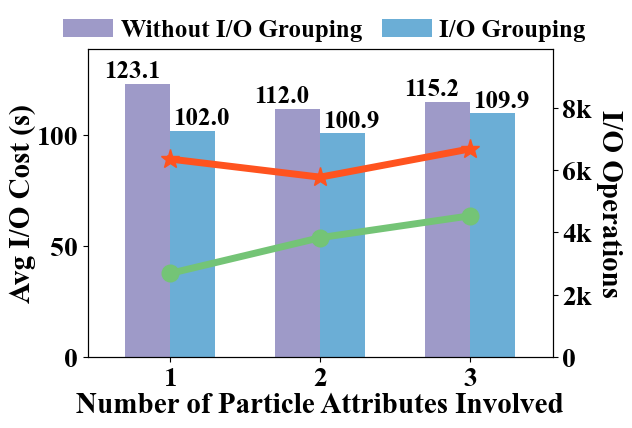

In [26]:
# only keep the test_type with specific values: 5 and 25
plot_df = averaged_df[averaged_df['test_type'].isin([23, 25])]

# plot_df = averaged_df[averaged_df['test_type'].isin([1, 23, 25])]
# plot_df['IO_time'] = plot_df['IO_time'].apply(lambda x: np.log10(x) + 1)

plot_df = plot_df[plot_df['select_set_length'] <= 3]
# the value difference between test_type 1 and 25 is too large, so we use log scale


# log for query_result_size and chunk_range_size
# plot_df['query_result_size'] = plot_df['query_result_size'].apply(lambda x: np.log10(x))
# plot_df['chunk_range_size'] = plot_df['chunk_range_size'].apply(lambda x: np.log10(x))

fig, ax = plt.subplots()

# set figure size
# fig.set_size_inches(10, 5)
fig.set_size_inches(6, 4)

# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='test_type', values='IO_time').plot(kind='bar', ax=ax, width=0.6, color=['#9e9ac8', '#6baed6'])

# mark the number on the top of each bar before log
for i, p in enumerate(ax.patches):
    # ax.annotate(str(i), (p.get_x() - 0.14, p.get_height() + 3), fontsize=global_annotation_fontsize, fontweight='bold')
    # ax.annotate(str(round(10**p.get_height(), 2)), (p.get_x() * 1, p.get_height() * 1.02))
    if i <= 2:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.14, p.get_height() + 3), fontsize=global_annotation_fontsize, fontweight='bold')
    else:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.02, p.get_height() + 3), fontsize=global_annotation_fontsize, fontweight='bold')

legend = ax.legend(title='', loc='upper right', labels=['Without I/O Grouping', 'I/O Grouping'], fontsize=global_legend_fontsize, ncol=2, frameon=False, bbox_to_anchor=(1.12, 1.17), columnspacing=0.8, handletextpad=0.3)

for text in legend.get_texts():
    text.set_fontweight('bold')

plt.xticks(rotation=0)
# plt y range
plt.ylim(0, 139)
# x label
plt.xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize - 3, fontweight='bold', labelpad=1)
# y label
plt.ylabel("Avg I/O Cost (s)", fontsize=global_label_fontsize - 3, fontweight='bold', labelpad=0)

# current_values = plt.gca().get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))

# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
plt.gca().tick_params(axis='x', labelsize=global_tick_fontsize)

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# plot 'query_result_size', 'chunk_range_size' in the same figure as the plot and use right y-axis with test_type = 25
ax2 = ax.twinx()
# ax2.set_xlim((ax.get_xlim()))
# with point * as marker
# select_set_length is the x-axis and start from 0
plot_df['select_set_length'] = plot_df['select_set_length'] - 1
plot_df[averaged_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='direct_io_number').plot(kind='line', ax=ax2, color='#ff531f', marker='*', markersize=14, linewidth=5)
plot_df[averaged_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='grouping_io_number').plot(kind='line', ax=ax2, color='#74c476', marker='o', markersize=12, linewidth=5)


plt.ylim(0, 9900)

# y label
plt.ylabel("I/O Operations", fontsize=global_label_fontsize - 3, rotation=270, labelpad=22, fontweight='bold')
current_values = plt.gca().get_yticks()
plt.gca().yaxis.set_major_locator(MultipleLocator(2000))
plt.gca().set_yticklabels([f"{int(y / 1000)}k" if y != 0 else "0" for y in plt.gca().get_yticks()])
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed

# Remove the legend
plt.gca().get_legend().remove()
plt.yticks(fontweight='bold')
plt.savefig(proj_path + "plot/final/io_grouping_comparison_large_v2.pdf", bbox_inches='tight', pad_inches=0.01)

plt.show()

print()

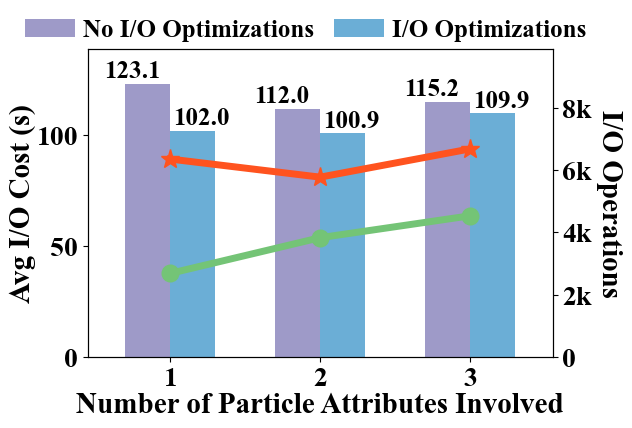

In [27]:
# only keep the test_type with specific values: 5 and 25
plot_df = averaged_df[averaged_df['test_type'].isin([23, 25])]

# plot_df = averaged_df[averaged_df['test_type'].isin([1, 23, 25])]
# plot_df['IO_time'] = plot_df['IO_time'].apply(lambda x: np.log10(x) + 1)

plot_df = plot_df[plot_df['select_set_length'] <= 3]
# the value difference between test_type 1 and 25 is too large, so we use log scale


# log for query_result_size and chunk_range_size
# plot_df['query_result_size'] = plot_df['query_result_size'].apply(lambda x: np.log10(x))
# plot_df['chunk_range_size'] = plot_df['chunk_range_size'].apply(lambda x: np.log10(x))

fig, ax = plt.subplots()

# set figure size
# fig.set_size_inches(10, 5)
fig.set_size_inches(6, 4)

# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='test_type', values='IO_time').plot(kind='bar', ax=ax, width=0.6, color=['#9e9ac8', '#6baed6'])

# mark the number on the top of each bar before log
for i, p in enumerate(ax.patches):
    # ax.annotate(str(i), (p.get_x() - 0.14, p.get_height() + 3), fontsize=global_annotation_fontsize, fontweight='bold')
    # ax.annotate(str(round(10**p.get_height(), 2)), (p.get_x() * 1, p.get_height() * 1.02))
    if i <= 2:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.14, p.get_height() + 3), fontsize=global_annotation_fontsize, fontweight='bold')
    else:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.02, p.get_height() + 3), fontsize=global_annotation_fontsize, fontweight='bold')

legend = ax.legend(title='', loc='upper right', labels=['No I/O Optimizations', 'I/O Optimizations'], fontsize=global_legend_fontsize, ncol=2, frameon=False, bbox_to_anchor=(1.12, 1.17), columnspacing=0.8, handletextpad=0.3)

for text in legend.get_texts():
    text.set_fontweight('bold')

plt.xticks(rotation=0)
# plt y range
plt.ylim(0, 139)
# x label
plt.xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize - 3, fontweight='bold', labelpad=1)
# y label
plt.ylabel("Avg I/O Cost (s)", fontsize=global_label_fontsize - 3, fontweight='bold', labelpad=0)

# current_values = plt.gca().get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))

# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
plt.gca().tick_params(axis='x', labelsize=global_tick_fontsize)

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# plot 'query_result_size', 'chunk_range_size' in the same figure as the plot and use right y-axis with test_type = 25
ax2 = ax.twinx()
# ax2.set_xlim((ax.get_xlim()))
# with point * as marker
# select_set_length is the x-axis and start from 0
plot_df['select_set_length'] = plot_df['select_set_length'] - 1
plot_df[averaged_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='direct_io_number').plot(kind='line', ax=ax2, color='#ff531f', marker='*', markersize=14, linewidth=5)
plot_df[averaged_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='grouping_io_number').plot(kind='line', ax=ax2, color='#74c476', marker='o', markersize=12, linewidth=5)


plt.ylim(0, 9900)

# y label
plt.ylabel("I/O Operations", fontsize=global_label_fontsize - 3, rotation=270, labelpad=22, fontweight='bold')
current_values = plt.gca().get_yticks()
plt.gca().yaxis.set_major_locator(MultipleLocator(2000))
plt.gca().set_yticklabels([f"{int(y / 1000)}k" if y != 0 else "0" for y in plt.gca().get_yticks()])
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed

# Remove the legend
plt.gca().get_legend().remove()
plt.yticks(fontweight='bold')
plt.savefig(proj_path + "plot/final/io_grouping_comparison_large_v3.pdf", bbox_inches='tight', pad_inches=0.01)

plt.show()

print()

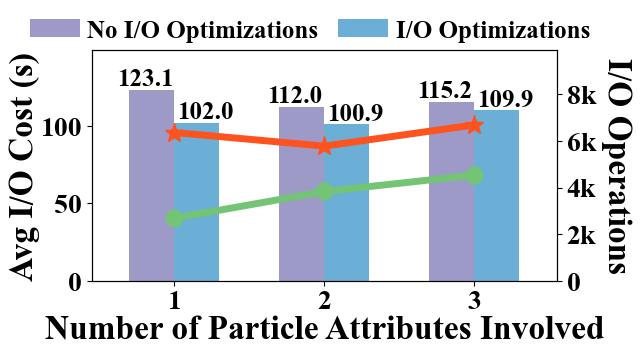

In [28]:
# only keep the test_type with specific values: 5 and 25
plot_df = averaged_df[averaged_df['test_type'].isin([23, 25])]

# plot_df = averaged_df[averaged_df['test_type'].isin([1, 23, 25])]
# plot_df['IO_time'] = plot_df['IO_time'].apply(lambda x: np.log10(x) + 1)

plot_df = plot_df[plot_df['select_set_length'] <= 3]
# the value difference between test_type 1 and 25 is too large, so we use log scale


# log for query_result_size and chunk_range_size
# plot_df['query_result_size'] = plot_df['query_result_size'].apply(lambda x: np.log10(x))
# plot_df['chunk_range_size'] = plot_df['chunk_range_size'].apply(lambda x: np.log10(x))

fig, ax = plt.subplots()

# set figure size
# fig.set_size_inches(10, 5)
fig.set_size_inches(6, 3)

# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='test_type', values='IO_time').plot(kind='bar', ax=ax, width=0.6, color=['#9e9ac8', '#6baed6'])

# mark the number on the top of each bar before log
for i, p in enumerate(ax.patches):
    # ax.annotate(str(i), (p.get_x() - 0.14, p.get_height() + 3), fontsize=global_annotation_fontsize, fontweight='bold')
    # ax.annotate(str(round(10**p.get_height(), 2)), (p.get_x() * 1, p.get_height() * 1.02))
    if i <= 2:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.08, p.get_height() + 3), fontsize=global_annotation_fontsize, fontweight='bold')
    else:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.02, p.get_height() + 3), fontsize=global_annotation_fontsize, fontweight='bold')

legend = ax.legend(title='', loc='upper right', labels=['No I/O Optimizations', 'I/O Optimizations'], fontsize=global_legend_fontsize, ncol=2, frameon=False, bbox_to_anchor=(1.12, 1.23), columnspacing=0.8, handletextpad=0.3)

for text in legend.get_texts():
    text.set_fontweight('bold')

plt.xticks(rotation=0)
# plt y range
plt.ylim(0, 149)
# x label
plt.xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, fontweight='bold', labelpad=1)
# y label
plt.ylabel("Avg I/O Cost (s)", fontsize=global_label_fontsize, fontweight='bold', labelpad=0)

# current_values = plt.gca().get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))

# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
plt.gca().tick_params(axis='x', labelsize=global_tick_fontsize)

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# plot 'query_result_size', 'chunk_range_size' in the same figure as the plot and use right y-axis with test_type = 25
ax2 = ax.twinx()
# ax2.set_xlim((ax.get_xlim()))
# with point * as marker
# select_set_length is the x-axis and start from 0
plot_df['select_set_length'] = plot_df['select_set_length'] - 1
plot_df[averaged_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='direct_io_number').plot(kind='line', ax=ax2, color='#ff531f', marker='*', markersize=14, linewidth=5)
plot_df[averaged_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='grouping_io_number').plot(kind='line', ax=ax2, color='#74c476', marker='o', markersize=12, linewidth=5)


plt.ylim(0, 9900)

# y label
plt.ylabel("I/O Operations", fontsize=global_label_fontsize , rotation=270, labelpad=26, fontweight='bold')
current_values = plt.gca().get_yticks()
plt.gca().yaxis.set_major_locator(MultipleLocator(2000))
plt.gca().set_yticklabels([f"{int(y / 1000)}k" if y != 0 else "0" for y in plt.gca().get_yticks()])
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed

# Remove the legend
plt.gca().get_legend().remove()
plt.yticks(fontweight='bold')
plt.savefig(proj_path + "plot/final/io_grouping_comparison_large_v4.pdf", bbox_inches='tight', pad_inches=0.01)

plt.show()

print()

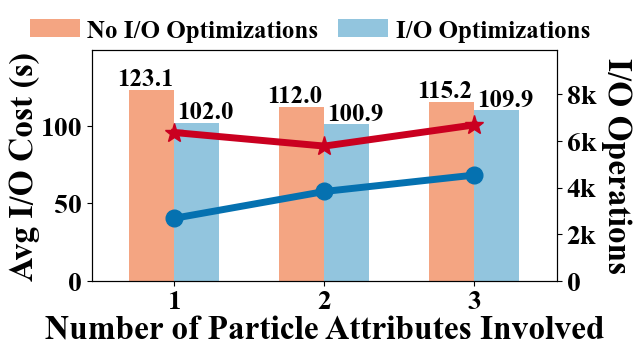

In [30]:
# only keep the test_type with specific values: 5 and 25
plot_df = averaged_df[averaged_df['test_type'].isin([23, 25])]

# plot_df = averaged_df[averaged_df['test_type'].isin([1, 23, 25])]
# plot_df['IO_time'] = plot_df['IO_time'].apply(lambda x: np.log10(x) + 1)

plot_df = plot_df[plot_df['select_set_length'] <= 3]
# the value difference between test_type 1 and 25 is too large, so we use log scale


# log for query_result_size and chunk_range_size
# plot_df['query_result_size'] = plot_df['query_result_size'].apply(lambda x: np.log10(x))
# plot_df['chunk_range_size'] = plot_df['chunk_range_size'].apply(lambda x: np.log10(x))

fig, ax = plt.subplots()

# set figure size
# fig.set_size_inches(10, 5)
fig.set_size_inches(6, 3)

# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='select_set_length', columns='test_type', values='IO_time').plot(kind='bar', ax=ax, width=0.6, color=['#f4a582', '#92c5de'])

# mark the number on the top of each bar before log
for i, p in enumerate(ax.patches):
    # ax.annotate(str(i), (p.get_x() - 0.14, p.get_height() + 3), fontsize=global_annotation_fontsize, fontweight='bold')
    # ax.annotate(str(round(10**p.get_height(), 2)), (p.get_x() * 1, p.get_height() * 1.02))
    if i <= 2:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.08, p.get_height() + 3), fontsize=global_annotation_fontsize, fontweight='bold')
    else:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.02, p.get_height() + 3), fontsize=global_annotation_fontsize, fontweight='bold')

legend = ax.legend(title='', loc='upper right', labels=['No I/O Optimizations', 'I/O Optimizations'], fontsize=global_legend_fontsize, ncol=2, frameon=False, bbox_to_anchor=(1.12, 1.23), columnspacing=0.8, handletextpad=0.3)

for text in legend.get_texts():
    text.set_fontweight('bold')

plt.xticks(rotation=0)
# plt y range
plt.ylim(0, 149)
# x label
plt.xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, fontweight='bold', labelpad=1)
# y label
plt.ylabel("Avg I/O Cost (s)", fontsize=global_label_fontsize, fontweight='bold', labelpad=0)

# current_values = plt.gca().get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))

# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
plt.gca().tick_params(axis='x', labelsize=global_tick_fontsize)

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# plot 'query_result_size', 'chunk_range_size' in the same figure as the plot and use right y-axis with test_type = 25
ax2 = ax.twinx()
# ax2.set_xlim((ax.get_xlim()))
# with point * as marker
# select_set_length is the x-axis and start from 0
plot_df['select_set_length'] = plot_df['select_set_length'] - 1
plot_df[averaged_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='direct_io_number').plot(kind='line', ax=ax2, color='#ca0020', marker='*', markersize=14, linewidth=5)
plot_df[averaged_df['test_type'] == 25].pivot(index='select_set_length', columns='test_type', values='grouping_io_number').plot(kind='line', ax=ax2, color='#0571b0', marker='o', markersize=12, linewidth=5)


plt.ylim(0, 9900)

# y label
plt.ylabel("I/O Operations", fontsize=global_label_fontsize , rotation=270, labelpad=26, fontweight='bold')
current_values = plt.gca().get_yticks()
plt.gca().yaxis.set_major_locator(MultipleLocator(2000))
plt.gca().set_yticklabels([f"{int(y / 1000)}k" if y != 0 else "0" for y in plt.gca().get_yticks()])
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# Adjust tick label fontsize
plt.gca().tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed

# Remove the legend
plt.gca().get_legend().remove()
plt.yticks(fontweight='bold')
plt.savefig(proj_path + "plot/final/io_grouping_comparison_large_v5.pdf", bbox_inches='tight', pad_inches=0.01)

plt.show()

print()